# Curating samples from the xView dataset

Pipeline so far (previous notebooks in this series):
- select a promising image tile (e.g. a lot of cars, visually selected etc)
- sample locations from there and output to `to_annotate` folder, with a separate dataframe per tile, pre-annotated (note, these images are **not** the same as will be fed to model, they have an extended bbox to help visual inspection) 
- annotate roads interactively using `ipyannotations` and append the labels as a column, then save

This notebooks reads in all the annotated dataframes, and also adds random locations (which will not have labels, to boost sample size and leverage DEARs capability for semi-supervision)

### WARNING: in xView_0 there was a bug - correcting here

Partway through I realised that B marking was faulty as forgot to divide by `res**2` for the built_area, and corrected it

In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys

import time as tm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from functools import partial

sys.path.append('..')

import src.plotting as splo
import src.data_utils as sdut
import src.geometry as sgeo
import src.sampling as ssam

## Set up namespace, e.g. point to data

In [3]:
data_path = '../data/xView/train_images-subset/'
label_paths = [
    '../data/xView/labels_0_fix/','../data/xView/labels_1/'
]
resolution = 128

out_path = '../data/xView_1/images/'
out_label_path = '../data/xView_1/labels.csv'

os.makedirs( out_path, exist_ok= True)

In [4]:
def combo_string(x):
    if x['roads'] == -1:
        return ''
    else:
        return str(x['buildings'])+str(x['roads'])+str(x['cars'])

def combine_labels( folders, res= 128, add_unlabelled= False):
    label_files = []
    _ = [
        label_files.extend( [f'{folder}{x}' for x in os.listdir( folder)]) for folder in folders
    ]
    assert all([f.endswith('.csv') for f in label_files])
    df = pd.DataFrame()
    for file_ in label_files:
        df_ = pd.read_csv( file_)
        to_drop = df_.loc[ df_['labels'] == 'reject'].index
        df_.drop( labels= to_drop, inplace= True)
        if max( df_['built_area']) > 4:
            print('Correcting built area to be a proportion of image!')
            df_['built_area'] = df_['built_area'] / (res**2)
        if 'im_name' in df_.columns:
            df_['im_source'] = df_['im_name'].str.split('_').map( lambda x: x[0])
            df_['image'] = 'tif' + df_['im_source'] + '_x' + df_['xs'].astype(str) + '_y' + df_['ys'].astype(str) + '.png'
        else:
            df_['im_source'] = df_['image'].str.split('_').map( lambda x: x[0]).str.replace('tif','')
        df_['buildings'] = ( df_['built_area'] > 0.25).astype(int)
        df_['cars'] = (df_['n_cars'] + df_['n_bus_trucks'] > 0).astype(int)
        df_['roads'] = df_['roads'].fillna(0).astype(int)
        print(f'File {file_}, keeping {len(df_)} entries.')
        df = pd.concat([df,df_])
    df['bbox_np'] = df['bbox_np'].map( sdut.bbox_from_str)
    df.loc[ df['labels']=='unlabel',['buildings','roads','cars']] = -1, -1, -1
    df['B_R_C'] = df.apply( combo_string, axis= 1)
    df.reset_index( inplace= True, drop= True)
    return df


def add_jittered( dfs, x_off, y_off, xmax, ymax, res= 128):
    im_name = dfs['im_source'].values[0]
    df_new = dfs[['xs','ys']].copy()
    # offset and add jitter:
    df_new['xs'] += np.sign(x_off)*(abs(x_off) + np.random.uniform(1,5,len(df_new)).astype(int))
    df_new['ys'] += np.sign(y_off)*(abs(y_off) + np.random.uniform(2,10,len(df_new)).astype(int))
    shift_ = int(res/2)
    to_drop = df_new.loc[ 
        (df_new['xs'] < shift_) | (df_new['ys'] < shift_) | 
        (df_new['xs']> xmax-shift_) | (df_new['ys']> ymax-shift_)
    ].index
    df_new.drop( labels= to_drop, inplace= True)
    df_new['bbox_np'] = df_new.apply(
        lambda x: ssam.square_bbox_around( x['xs'], x['ys'], res= res), axis= 1
    ).map(
        lambda x: [int(y) for y in x]
    )
    df_new[['buildings','roads','cars']] = -1,-1,-1
    df_new['image'] = df_new.apply( lambda x: ssam.name_sample_image( im_name, x['xs'], x['ys']), axis= 1)
    return df_new

def add_unlabelled_safe( dfs, im_dims, im_name, res= 128):
    """
    This assumes dfs is a slice of the larger frame.
    """
    xmax, ymax = im_dims
    n_lab = len( dfs.loc[ dfs['roads']>= 0])
    cols_output = ['image','xs','ys','bbox_np','buildings','roads','cars']
    dfs_ = dfs[cols_output].copy()
    for x_off, y_off in [(40,60),(-60,40),(-40,-40),(60,-40)]:
        df_new = add_jittered( dfs, x_off, y_off, xmax, ymax)
        dfs_ = pd.concat([ dfs_, df_new])
    dfs_.reset_index( drop=True, inplace=True)
    dfs_.sort_values(by=['xs','ys'],inplace=True)
    pre_filt = len(dfs_)
    dfs_ = ssam.filter_xy( dfs_, int( res/ 4), rounds= 3)
    print(f'Filtered out {pre_filt - len(dfs_)}')
    n_lab_new = len( dfs_.loc[ dfs_['roads'] >=0])
    try:
        assert n_lab_new == n_lab
    except AssertionError:
        print(f'Lost {n_lab - n_lab_new} labels')
    return dfs_

def process_slice_for_image( df, im_src_, data_path):
    im_src_path = f'{data_path}{im_src_}.tif'
    print(f'Loading {im_src_path}')
    image_ = np.array( Image.open( im_src_path))
    xmax, ymax, _ = image_.shape
    dfs = df.loc[ df['im_source'] == im_src_]
    dfs_ = add_unlabelled_safe( dfs, (xmax, ymax), im_src_, res= resolution)
    dfs_[['mean','var']] = None, None
    for id_, bbox_ in zip( dfs_.index, dfs_['bbox_np']):
        crop = sgeo.crop_to_bbox( image_, bbox_)
        dfs_.loc[ id_, 'mean'] = crop.mean()
        dfs_.loc[ id_, 'var'] = crop.var()
    return dfs_, image_

## Investigate data, try things out 

_**you can even add fancy markdown throughout to document things..?**_

In [5]:
df = combine_labels( label_paths)
df.shape

Correcting built area to be a proportion of image!
File ../data/xView/labels_0_fix/for_tiff102.csv, keeping 411 entries.
Correcting built area to be a proportion of image!
File ../data/xView/labels_0_fix/for_tiff1037.csv, keeping 142 entries.
Correcting built area to be a proportion of image!
File ../data/xView/labels_0_fix/for_tiff104.csv, keeping 117 entries.
Correcting built area to be a proportion of image!
File ../data/xView/labels_0_fix/for_tiff105.csv, keeping 113 entries.
Correcting built area to be a proportion of image!
File ../data/xView/labels_0_fix/for_tiff1051.csv, keeping 225 entries.
Correcting built area to be a proportion of image!
File ../data/xView/labels_0_fix/for_tiff106.csv, keeping 287 entries.
Correcting built area to be a proportion of image!
File ../data/xView/labels_0_fix/for_tiff1063.csv, keeping 169 entries.
Correcting built area to be a proportion of image!
File ../data/xView/labels_0_fix/for_tiff1065.csv, keeping 104 entries.
Correcting built area to be 

(4380, 18)

In [6]:
df.head(3)

,xs,ys,bbox_np,bbox_context,bbox_in_context,built_area,n_cars,n_bus_trucks,roads_old,im_name,labels_old,roads,labels,im_source,image,buildings,cars,B_R_C
0,65,1613,"[1, 1549, 129, 1677]","[0, 1485, 256, 1741]","[1, 64, 129, 192]",1.348145,0.0,0.0,NaN,102_0.png,unlabel,-1,unlabel,102,tif102_x65_y1613.png,-1,-1,
1,66,1445,"[2, 1381, 130, 1509]","[0, 1317, 256, 1573]","[2, 64, 130, 192]",0.208496,0.0,0.0,NaN,102_1.png,unlabel,-1,unlabel,102,tif102_x66_y1445.png,-1,-1,
2,79,1999,"[15, 1935, 143, 2063]","[0, 1871, 256, 2127]","[15, 64, 143, 192]",0.404419,0.0,0.0,1.0,102_6.png,road,1,road,102,tif102_x79_y1999.png,1,0,110


In [7]:
df_ = df.loc[ df['labels'] != 'unlabel']
df_.shape

(3229, 18)

<Axes: xlabel='B_R_C'>

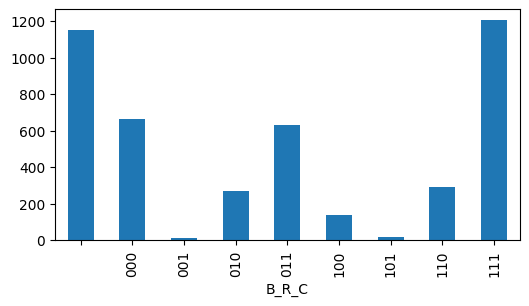

In [8]:
_, ax = plt.subplots( figsize= (6,3))
df.groupby('B_R_C').count()['xs'].plot(kind='bar', ax= ax)

In [9]:
df.groupby('im_source').agg({'built_area':['min','max']})

built_area          
                 min       max
im_source                     
102         0.000000  1.485840
1037        0.000000  0.945312
104         0.000000  1.320862
105         0.000000  1.399902
1051        0.000000  1.268982
106         0.000000  0.993469
1063        0.000000  0.923584
1065        0.000000  1.470459
107         0.000000  1.839600
109         0.000000  1.352478
110         0.160767  1.157593
1121        0.000000  1.383606
1124        0.000000  1.199646
1132        0.000000  1.204712
42          0.000000  1.567505
43          0.000000  1.153015
46          0.000000  1.916870

testing the mechanics is ok..

Loading ../data/xView/train_images-subset/1037.tif
Filtered out 17
Dropping 113.


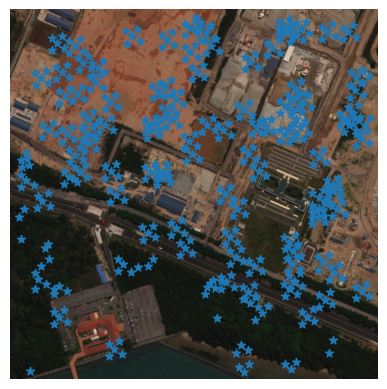

In [30]:
dfs_, image_ = process_slice_for_image( df, '1037', data_path= data_path)
ax = splo.plot_single(image_)
to_drop = dfs_.loc[ (dfs_['var']<60) & (dfs_['mean']<25) &(dfs_['roads']==-1)].index
print(f'Dropping {len(to_drop)}.')
dfs_.drop( to_drop, inplace= True)
ax.scatter(dfs_['ys'], dfs_['xs'], marker='*')

<Axes: >

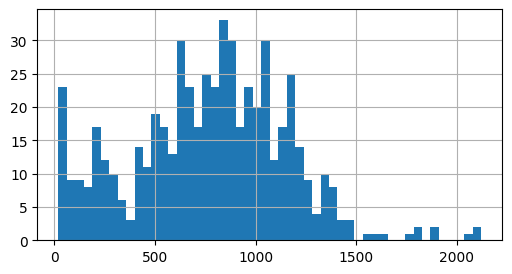

In [31]:
_ = plt.subplots( figsize= (6,3))
dfs_['var'].hist( bins= 50)

In [32]:
ims_to_skip = ['1037']

Loop through the unique source images, for each add further unlabelled data (some offset, some random)

In [33]:
start = tm.time()
df_out = pd.DataFrame()
for im_src_ in df['im_source'].unique():
    if im_src_ not in ims_to_skip:
        dfs_, image_ = process_slice_for_image( df, im_src_, data_path= data_path)
        # drop low-mean low-variance samples:
        to_drop = dfs_.loc[ (dfs_['var']<60) & (dfs_['mean']<25) &(dfs_['roads']==-1)].index
        dfs_.drop( to_drop, inplace= True)
        df_out = pd.concat( [df_out, dfs_])
        for bbox_, name_ in zip( dfs_['bbox_np'], dfs_['image']):
            Image.fromarray( sgeo.crop_to_bbox( image_, bbox_)).save( f'{out_path}{name_}')
        print(f'Output {len(dfs_)} to {out_path}\n')
df_out.reset_index( drop= True, inplace= True)
df_out['B_R_C'] = df_out.apply( combo_string, axis= 1)

df_out.to_csv( out_label_path, index= False)

print(f'Took {np.round((tm.time()-start)/60,3)} mins, output {len(df_out)} images, saved labels to {out_label_path}.')
len(df_out.loc[ df_out['B_R_C']!='']), len(df_out)

Loading ../data/xView/train_images-subset/102.tif
Filtered out 32
Output 1957 to ../data/xView_1/images/

Loading ../data/xView/train_images-subset/104.tif
Filtered out 10
Output 532 to ../data/xView_1/images/

Loading ../data/xView/train_images-subset/105.tif
Filtered out 10
Output 517 to ../data/xView_1/images/

Loading ../data/xView/train_images-subset/1051.tif
Filtered out 34
Output 1055 to ../data/xView_1/images/

Loading ../data/xView/train_images-subset/106.tif
Filtered out 25
Output 1345 to ../data/xView_1/images/

Loading ../data/xView/train_images-subset/1063.tif
Filtered out 55
Lost 5 labels
Output 767 to ../data/xView_1/images/

Loading ../data/xView/train_images-subset/1065.tif
Filtered out 41
Lost 3 labels
Output 458 to ../data/xView_1/images/

Loading ../data/xView/train_images-subset/107.tif
Filtered out 30
Output 1174 to ../data/xView_1/images/

Loading ../data/xView/train_images-subset/109.tif
Filtered out 60
Lost 1 labels
Output 1655 to ../data/xView_1/images/

Loadi

(3100, 19895)

<Axes: xlabel='B_R_C'>

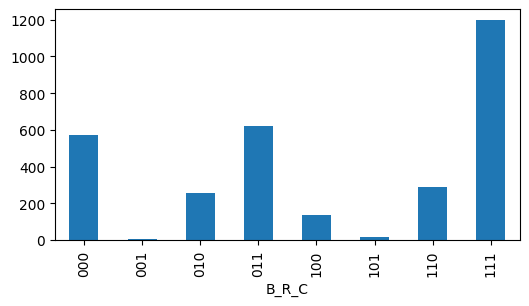

In [34]:
_, ax = plt.subplots( figsize= (6,3))
dfg = df_out.groupby('B_R_C').count()['xs']
dfg.loc[ dfg.index != ''].plot(kind='bar', ax= ax)

In [35]:
len(df_out['image'].unique()) == len(df_out)

True

In [36]:
set(df_out['image'].unique()) == set(os.listdir( out_path))

True

In [37]:
df_out.head(5)

,image,xs,ys,bbox_np,buildings,roads,cars,mean,var,B_R_C
0,tif102_x65_y1613.png,65,1613,"[1, 1549, 129, 1677]",-1,-1,-1,46.888713,1786.789251,
1,tif102_x66_y1445.png,66,1445,"[2, 1381, 130, 1509]",-1,-1,-1,18.775716,244.384511,
2,tif102_x74_y1273.png,74,1273,"[10, 1209, 138, 1337]",-1,-1,-1,23.445801,86.919141,
3,tif102_x79_y1999.png,79,1999,"[15, 1935, 143, 2063]",1,1,0,76.229797,1031.909819,110
4,tif102_x80_y2384.png,80,2384,"[16, 2320, 144, 2448]",-1,-1,-1,46.584839,1455.796147,
